## SAM 3 video segmentation — per-episode point-only batch (one task at a time)

Process every episode in a single task using **point prompts only**, with an **independent SAM 3 session per episode** (avoids cross-video memory bleed). Tasks stay independent: one task per notebook run.

### Workflow
Run setup cells once. Then loop through episodes by re-running this three-cell rhythm:

1. **(A) Open next episode** — auto-advances to the next pending episode, stages its head-cam frames, opens the click picker on frame 0.
2. **(B) Preview frame-0 mask** — applies your current points, shows the resulting mask. Re-runnable: click more points in the still-live picker widget and re-run B until the mask looks right.
3. **(C) Commit** — propagates through the full clip, saves masks to `<episode>/mask/`, closes the session, advances the counter.

Loop A → B → C → A → … until the task is done. Always overwrites existing masks. Per-episode failures are logged and reported in the rolling summary.

In [11]:
!nvidia-smi

Sat May  9 21:29:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.119.02             Driver Version: 580.119.02     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090        Off |   00000000:01:00.0  On |                  N/A |
|  0%   40C    P8             23W /  600W |    9459MiB /  32607MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Imports & build predictor

In [12]:
import copy
import glob
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
import sam3
import torch
from PIL import Image
from sam3.model_builder import build_sam3_video_predictor
from sam3.visualization_utils import (
    load_frame,
    prepare_masks_for_visualization,
    visualize_formatted_frame_output,
)

plt.rcParams["axes.titlesize"] = 12
plt.rcParams["figure.titlesize"] = 12


def propagate_in_video(predictor, session_id, start_frame_index=0):
    """Propagate forward+backward from a given frame.

    Passing start_frame_index=0 explicitly is required for the point-prompt
    (instance-tracking) path: that path doesn't populate `previous_stages_out`,
    so without an explicit start the predictor raises
    'No prompts are received on any frames'. Text/box prompts work either way.
    """
    outputs_per_frame = {}
    for response in predictor.handle_stream_request(
        request=dict(
            type="propagate_in_video",
            session_id=session_id,
            start_frame_index=start_frame_index,
        )
    ):
        outputs_per_frame[response["frame_index"]] = response["outputs"]
    return outputs_per_frame

In [13]:
gpus_to_use = list(range(torch.cuda.device_count()))
predictor = build_sam3_video_predictor(gpus_to_use=gpus_to_use)

INFO 2026-05-09 21:29:31,537 202573 sam3_video_predictor.py: 109: using the following GPU IDs: [0]
INFO 2026-05-09 21:29:31,538 202573 sam3_video_predictor.py: 125: 


	*** START loading model on all ranks ***


INFO 2026-05-09 21:29:31,538 202573 sam3_video_predictor.py: 127: loading model on rank=0 with world_size=1 -- this could take a while ...
INFO 2026-05-09 21:29:33,843 202573 sam3_video_base.py: 348: setting max_num_objects=10000 and num_obj_for_compile=16
INFO 2026-05-09 21:29:34,996 202573 sam3_video_predictor.py: 129: loading model on rank=0 with world_size=1 -- DONE locally
INFO 2026-05-09 21:29:34,997 202573 sam3_video_predictor.py: 140: 


	*** DONE loading model on all ranks ***




### Configure task

In [14]:
DATASET_ROOT     = os.path.expanduser("~/datasets/manipulation_dataset_v0.1")
HEAD_CAM_SUFFIX  = "_color_0.jpg"   # <-- edit me to switch cameras  (e.g. _color_2.jpg)
TASK             = "chip_pick"      # <-- edit me  (chip_pick | kit_pick | mask_pick)
OBJ_ID           = 1               # SAM 3 object id used for the single instance we track

# Derived from HEAD_CAM_SUFFIX so different cameras get their own staging + mask dirs.
# "_color_1.jpg" -> "color_1"     mask dir: episode_xxxx/mask_color_1/
# "_color_2.jpg" -> "color_2"     mask dir: episode_xxxx/mask_color_2/
CAM_NAME = HEAD_CAM_SUFFIX.lstrip("_").rsplit(".", 1)[0]

task_dir = os.path.join(DATASET_ROOT, TASK)
assert os.path.isdir(task_dir), f"missing task dir: {task_dir}"
all_episodes = sorted(
    d for d in os.listdir(task_dir)
    if d.startswith("episode_") and os.path.isdir(os.path.join(task_dir, d))
)

# State machine carrying position across cell runs.
batch_state = {
    "next_idx":  0,        # index into all_episodes for the *next* episode to start
    "current":   None,     # dict | None  - currently-staged episode info
    "successes": [],
    "failures":  [],       # list of (episode, error_repr)
}
POINTS_PIXEL = []          # cleared automatically when advancing to a new episode

print(f"task: {TASK}    cam: {CAM_NAME}    episodes: {len(all_episodes)}  ({all_episodes[0]} ... {all_episodes[-1]})")
print(f"staging dir per episode:  <episode>/{CAM_NAME}_frames/")
print(f"mask dir per episode:     <episode>/mask_{CAM_NAME}/")

task: chip_pick    cam: color_0    episodes: 52  (episode_0001 ... episode_0052)
staging dir per episode:  <episode>/color_0_frames/
mask dir per episode:     <episode>/mask_color_0/


### Per-episode helpers

In [15]:
def stage_head_cam(episode_dir):
    """Build (or refresh) <episode>/<CAM_NAME>_frames/00000.jpg ... pointing at *<HEAD_CAM_SUFFIX> files.
    Returns (stage_dir, head_frames_src). Idempotent."""
    colors_dir = os.path.join(episode_dir, "colors")
    head_frames_src = sorted(glob.glob(os.path.join(colors_dir, f"*{HEAD_CAM_SUFFIX}")))
    if not head_frames_src:
        raise RuntimeError(f"no *{HEAD_CAM_SUFFIX} files in {colors_dir}")
    stage_dir = os.path.join(episode_dir, f"{CAM_NAME}_frames")
    os.makedirs(stage_dir, exist_ok=True)
    for old in glob.glob(os.path.join(stage_dir, "*.jpg")):
        if os.path.islink(old) or os.path.isfile(old):
            os.unlink(old)
    for i, src in enumerate(head_frames_src):
        os.symlink(os.path.abspath(src), os.path.join(stage_dir, f"{i:05d}.jpg"))
    return stage_dir, head_frames_src


def apply_point_prompt(predictor, session_id, head_frames_src):
    """Apply POINTS_PIXEL to frame 0 with OBJ_ID. Returns response['outputs']."""
    if not POINTS_PIXEL:
        raise RuntimeError("POINTS_PIXEL is empty — click at least one positive point")
    with Image.open(head_frames_src[0]) as im:
        W_img, H_img = im.size
    xs_rel = [x / W_img for (x, _, _) in POINTS_PIXEL]
    ys_rel = [y / H_img for (_, y, _) in POINTS_PIXEL]
    labels = [lab     for (_, _, lab) in POINTS_PIXEL]
    points = torch.tensor(list(zip(xs_rel, ys_rel)), dtype=torch.float32)
    point_labels = torch.tensor(labels, dtype=torch.int32)
    resp = predictor.handle_request(dict(
        type="add_prompt", session_id=session_id,
        frame_index=0, points=points, point_labels=point_labels,
        obj_id=OBJ_ID,
    ))
    return resp["outputs"]


def save_masks(outputs_per_frame_raw, head_frames_src, episode_dir):
    """Write 3-channel RGB binary masks at head-cam resolution to <episode>/mask_<CAM_NAME>/. Always overwrites."""
    mask_dir = os.path.join(episode_dir, f"mask_{CAM_NAME}")
    os.makedirs(mask_dir, exist_ok=True)
    for old in glob.glob(os.path.join(mask_dir, "*.png")):
        os.unlink(old)

    with Image.open(head_frames_src[0]) as im:
        target_w, target_h = im.size
    any_out = next(iter(outputs_per_frame_raw.values()))
    Hm, Wm = any_out["out_binary_masks"].shape[-2:]

    n_with_fg = 0
    for fidx in range(len(head_frames_src)):
        fg = np.zeros((Hm, Wm), dtype=bool)
        out = outputs_per_frame_raw.get(fidx)
        if out is not None:
            bin_masks = np.asarray(out["out_binary_masks"])
            if bin_masks.size:
                fg = np.any(bin_masks, axis=0)
        gray = Image.fromarray((fg.astype(np.uint8) * 255), mode="L").resize(
            (target_w, target_h), resample=Image.NEAREST
        )
        rgb = Image.merge("RGB", (gray, gray, gray))
        rgb.save(os.path.join(mask_dir, f"{fidx:05d}_mask.png"))
        if fg.any():
            n_with_fg += 1
    return len(head_frames_src), n_with_fg


def _print_progress():
    s, f = len(batch_state["successes"]), len(batch_state["failures"])
    n = len(all_episodes)
    print(f"progress: {batch_state['next_idx']}/{n} processed   ({s} ok, {f} failed)")
    if batch_state["failures"]:
        print("  failures:")
        for ep, err in batch_state["failures"]:
            print(f"    {ep}: {err}")

### (A) Open next episode — stage + click picker

Re-run this cell each time you start a new episode. If a current episode is already staged (e.g., you re-ran this by accident), it just re-opens the picker without losing your existing clicks.

**Left-click** = positive point (on the target).  **Right-click** = negative point.  **Middle-click** = remove the nearest existing point (use this if you mis-clicked).

frame loading (image folder) [rank=0]:   0%|          | 0/222 [00:00<?, ?it/s]

frame loading (image folder) [rank=0]: 100%|██████████| 222/222 [00:01<00:00, 170.02it/s]
INFO 2026-05-09 22:45:06,568 202573 sam3_base_predictor.py: 146: started new session dbd3e3b5-2a11-497a-a858-3301ed5e52d6


staged [52/52] episode_0052  (222 frames)


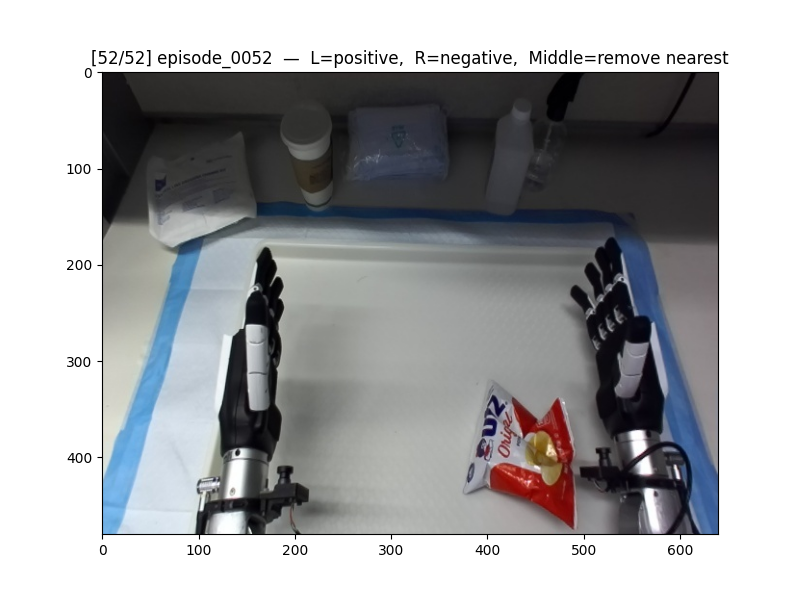

In [171]:
%matplotlib widget

if batch_state["current"] is None:
    idx = batch_state["next_idx"]
    if idx >= len(all_episodes):
        print(f"All {len(all_episodes)} episodes processed for task '{TASK}'.")
        _print_progress()
    else:
        ep = all_episodes[idx]
        episode_dir = os.path.join(task_dir, ep)
        stage_dir, head_frames_src = stage_head_cam(episode_dir)
        resp = predictor.handle_request(dict(type="start_session", resource_path=stage_dir))
        session_id = resp["session_id"]
        batch_state["current"] = {
            "ep": ep, "episode_dir": episode_dir,
            "stage_dir": stage_dir, "head_frames_src": head_frames_src,
            "session_id": session_id,
        }
        POINTS_PIXEL.clear()
        print(f"staged [{idx+1}/{len(all_episodes)}] {ep}  ({len(head_frames_src)} frames)")

_state = batch_state["current"]
if _state is not None:
    _frame0 = np.array(Image.open(_state["head_frames_src"][0]))
    H_img, W_img = _frame0.shape[:2]
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(_frame0)
    ax.set_title(
        f"[{batch_state['next_idx']+1}/{len(all_episodes)}] {_state['ep']}"
        f"  \u2014  L=positive,  R=negative,  Middle=remove nearest"
    )

    # parallel lists so we can remove an artist when its point is removed
    _point_artists = []

    def _draw_marker(x, y, lab):
        if lab == 1:
            (artist,) = ax.plot(x, y, marker="*", color="lime", markersize=18, markeredgecolor="black")
        else:
            (artist,) = ax.plot(x, y, marker="X", color="red", markersize=14, markeredgecolor="black")
        return artist

    # repaint any pre-existing markers (idempotent re-runs)
    for x, y, lab in POINTS_PIXEL:
        _point_artists.append(_draw_marker(x, y, lab))

    def _on_click(event):
        if event.inaxes != ax or event.xdata is None or event.ydata is None:
            return
        x, y = int(event.xdata), int(event.ydata)
        if event.button == 1:               # left = positive
            POINTS_PIXEL.append((x, y, 1))
            _point_artists.append(_draw_marker(x, y, 1))
        elif event.button == 3:             # right = negative
            POINTS_PIXEL.append((x, y, 0))
            _point_artists.append(_draw_marker(x, y, 0))
        elif event.button == 2:             # middle = remove nearest
            if not POINTS_PIXEL:
                return
            dists = [(px - x) ** 2 + (py - y) ** 2 for (px, py, _) in POINTS_PIXEL]
            k = int(np.argmin(dists))
            removed = POINTS_PIXEL.pop(k)
            artist = _point_artists.pop(k)
            artist.remove()
            print(f"removed point {removed}  (now {len(POINTS_PIXEL)} total)")
        else:
            return
        fig.canvas.draw_idle()
        if event.button in (1, 3):
            print(f"POINTS_PIXEL ({len(POINTS_PIXEL)}): {POINTS_PIXEL}")

    _cid = fig.canvas.mpl_connect("button_press_event", _on_click)
    plt.show()

### (B) Preview frame-0 mask

Re-runnable. Each call resets the session, re-applies the current points, and shows the resulting mask. Add more clicks in the still-live picker widget above and re-run this cell to iterate.

episode_0052 frame 0: detected 1 object(s), ids=[1]


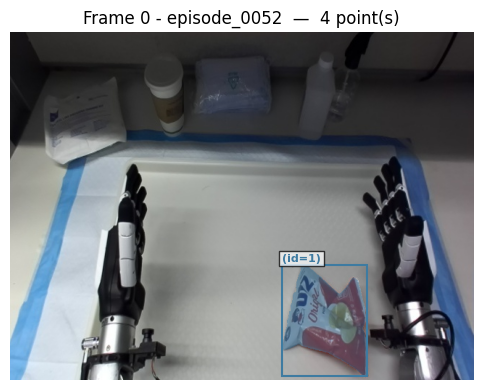

In [172]:
%matplotlib inline
_state = batch_state.get("current")
assert _state is not None, "no current episode — run cell (A) first"
assert POINTS_PIXEL, "click at least one positive point in cell (A) first"

predictor.handle_request(dict(type="reset_session", session_id=_state["session_id"]))
out = apply_point_prompt(predictor, _state["session_id"], _state["head_frames_src"])
print(f"{_state['ep']} frame 0: detected {len(out['out_obj_ids'])} object(s), ids={list(out['out_obj_ids'])}")

plt.close("all")
visualize_formatted_frame_output(
    0, _state["head_frames_src"],
    outputs_list=[prepare_masks_for_visualization({0: out})],
    titles=[f"{_state['ep']}  \u2014  {len(POINTS_PIXEL)} point(s)"],
    figsize=(6, 4),
)

### (C) Commit — propagate, save, close, advance

When the frame-0 mask in (B) looks right, run this cell. It propagates through the whole clip, writes the masks to `<episode>/mask/`, closes the session, and advances to the next episode. After it finishes, re-run cell (A) to start the next one.

In [173]:
_state = batch_state.get("current")
assert _state is not None, "no current episode — run cell (A) first"
ep = _state["ep"]
session_id = _state["session_id"]
head_frames_src = _state["head_frames_src"]
episode_dir = _state["episode_dir"]

try:
    if not POINTS_PIXEL:
        raise RuntimeError("no points clicked")
    # Make sure the session reflects the latest POINTS_PIXEL — reset + re-apply.
    predictor.handle_request(dict(type="reset_session", session_id=session_id))
    out0 = apply_point_prompt(predictor, session_id, head_frames_src)
    if len(out0["out_obj_ids"]) == 0:
        raise RuntimeError("no detection on frame 0")

    outputs_per_frame_raw = propagate_in_video(predictor, session_id, start_frame_index=0)
    n_saved, n_with_fg = save_masks(outputs_per_frame_raw, head_frames_src, episode_dir)
    batch_state["successes"].append(ep)
    print(f"OK   [{ep}]  {n_saved} masks  ({n_with_fg} non-empty)")
except Exception as e:
    batch_state["failures"].append((ep, repr(e)))
    print(f"FAIL [{ep}]  {e!r}")
finally:
    try:
        predictor.handle_request(dict(type="close_session", session_id=session_id))
    except Exception as e:
        print(f"  (close_session error: {e!r})")
    batch_state["current"] = None
    batch_state["next_idx"] += 1
    POINTS_PIXEL.clear()

_print_progress()
if batch_state["next_idx"] < len(all_episodes):
    print(f"\nRe-run cell (A) to open the next episode: {all_episodes[batch_state['next_idx']]}")

  0%|          | 0/222 [00:00<?, ?it/s]

0it [00:00, ?it/s]

INFO 2026-05-09 22:45:32,026 202573 sam3_base_predictor.py: 305: propagation ended in session dbd3e3b5-2a11-497a-a858-3301ed5e52d6


OK   [episode_0052]  222 masks  (222 non-empty)


INFO 2026-05-09 22:45:32,792 202573 sam3_base_predictor.py: 345: removed session dbd3e3b5-2a11-497a-a858-3301ed5e52d6


progress: 52/52 processed   (52 ok, 0 failed)


### (Optional) Skip current episode

Run this instead of (C) if the picker reveals the head cam doesn't actually contain the target. Closes the session without saving and advances the counter.

In [ ]:
_state = batch_state.get("current")
if _state is None:
    print("no current episode to skip")
else:
    ep = _state["ep"]
    try:
        predictor.handle_request(dict(type="close_session", session_id=_state["session_id"]))
    except Exception as e:
        print(f"  (close_session error: {e!r})")
    batch_state["failures"].append((ep, "skipped by user"))
    batch_state["current"] = None
    batch_state["next_idx"] += 1
    POINTS_PIXEL.clear()
    print(f"SKIPPED  [{ep}]")
    _print_progress()

### Cleanup (run when the whole task is done)

In [174]:
predictor.shutdown()